# 농어의 무게를 예측
```길이를 입력하면 무게를 예측하는 문제```

## 회귀
```프랜시스 골턴```
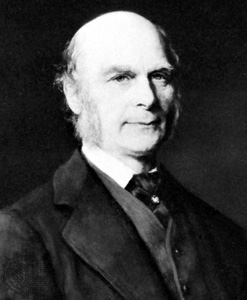

## k-최근접 이웃 회귀
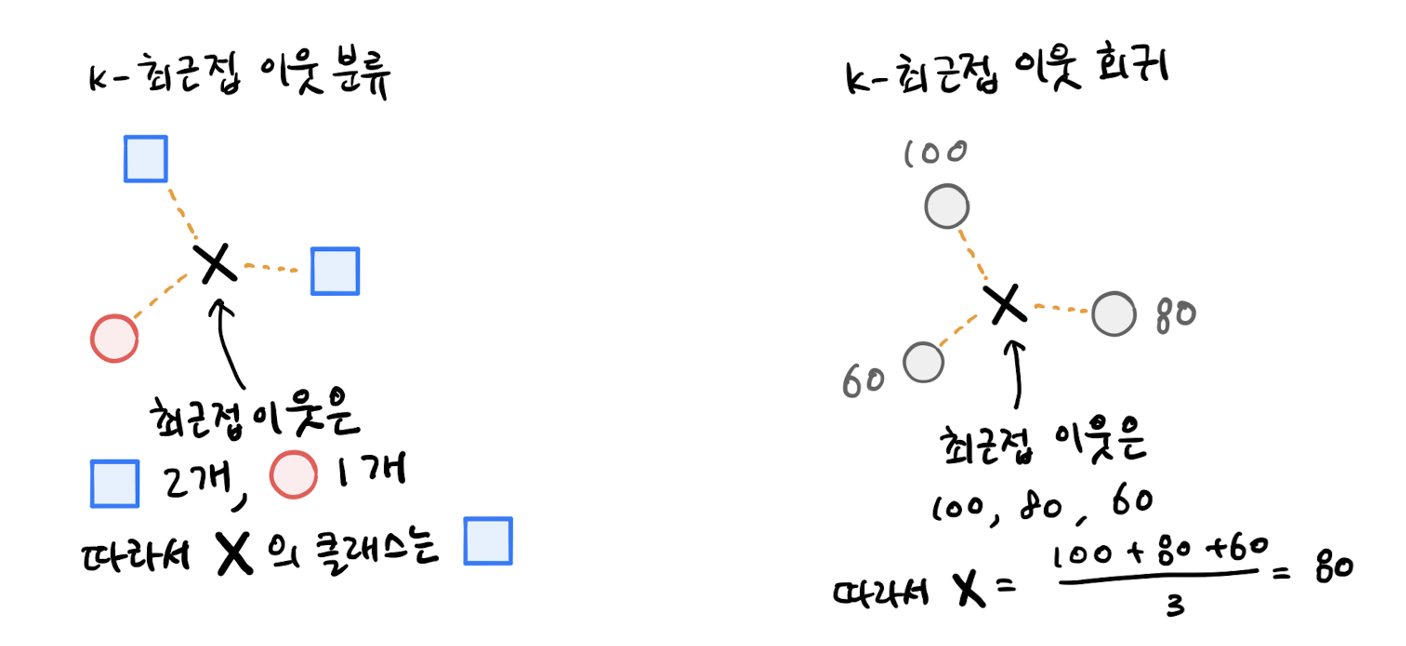


## 농어 데이터 준비

In [1]:
import numpy as np

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

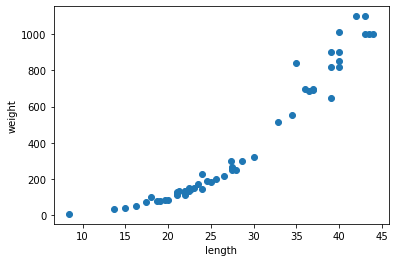

In [3]:
# 시각화
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [7]:
# 훈련 데이터와 테스트 데이터로 섞어서 나누기
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(perch_length, perch_weight, random_state=42)

print(train_input)
print(len(train_input))
print(train_target)
print(len(train_target))

print('-' * 100)

print(test_input)
print(len(test_input))
print(test_target)
print(len(test_target))

[19.6 22.  18.7 17.4 36.  25.  40.  39.  43.  22.  20.  22.  24.  27.5
 43.  40.  24.  21.  27.5 40.  32.8 26.5 36.5 13.7 22.7 15.  37.  35.
 28.7 23.5 39.  21.  23.  22.  44.  22.5 19.  37.  22.  25.6 42.  34.5]
42
[  85.  135.   78.   70.  700.  180.  850.  820. 1000.  120.   85.  130.
  225.  260. 1100.  900.  145.  115.  265. 1015.  514.  218.  685.   32.
  145.   40.  690.  840.  300.  170.  650.  110.  150.  110. 1000.  150.
   80.  700.  120.  197. 1100.  556.]
42
----------------------------------------------------------------------------------------------------
[ 8.4 18.  27.5 21.3 22.5 40.  30.  24.6 39.  21.  43.5 16.2 28.  27.3]
14
[   5.9  100.   250.   130.   130.   820.   320.   188.   900.   125.
 1000.    51.5  250.   300. ]
14


In [8]:
test_array = np.array([1, 2, 3, 4])
print(test_array)

[1 2 3 4]


In [9]:
test_array = test_array.reshape(2, 2)
print(test_array)

[[1 2]
 [3 4]]


In [10]:
test_array = test_array.reshape(4, 1)
print(test_array)

[[1]
 [2]
 [3]
 [4]]


In [11]:
test_array = test_array.reshape(-1, 1)
print(test_array)

[[1]
 [2]
 [3]
 [4]]


In [12]:
train_input = train_input.reshape(-1, 1)
train_input

array([[19.6],
       [22. ],
       [18.7],
       [17.4],
       [36. ],
       [25. ],
       [40. ],
       [39. ],
       [43. ],
       [22. ],
       [20. ],
       [22. ],
       [24. ],
       [27.5],
       [43. ],
       [40. ],
       [24. ],
       [21. ],
       [27.5],
       [40. ],
       [32.8],
       [26.5],
       [36.5],
       [13.7],
       [22.7],
       [15. ],
       [37. ],
       [35. ],
       [28.7],
       [23.5],
       [39. ],
       [21. ],
       [23. ],
       [22. ],
       [44. ],
       [22.5],
       [19. ],
       [37. ],
       [22. ],
       [25.6],
       [42. ],
       [34.5]])

In [13]:
test_input = test_input.reshape(-1, 1)
test_input

array([[ 8.4],
       [18. ],
       [27.5],
       [21.3],
       [22.5],
       [40. ],
       [30. ],
       [24.6],
       [39. ],
       [21. ],
       [43.5],
       [16.2],
       [28. ],
       [27.3]])

In [14]:
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


## 회귀에서 결과값을 판단할 때 사용하는 점수
- 평균정도 예측하면 0에 가깝다
- 정확히 예측하면 1에 가깝다
- 잘못예측하면 음수가 된다
```결정계수```
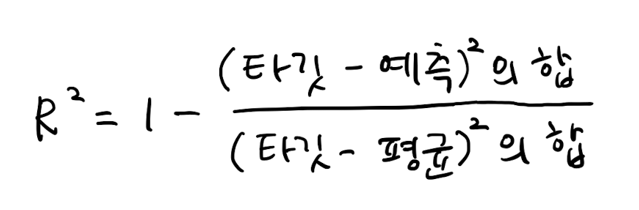

In [15]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()

knr.fit(train_input, train_target)

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                    weights='uniform')

In [16]:
print(knr.score(test_input, test_target))

0.9928094061010639


## 점수가 1에 가까우므로 예측이 잘되고 있다

# 평균 절대값 오차
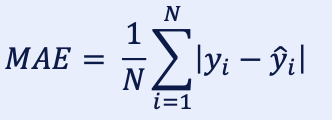

In [17]:
from sklearn.metrics import mean_absolute_error

test_prediction = knr.predict(test_input)

# (실제값, 예측값)
mae = mean_absolute_error(test_target, test_prediction)

print(mae)

19.157142857142862


In [18]:
# 학습된 데이터로 결정계수값을 출력해보자
print(knr.score(train_input, train_target))

0.9698823289099255


### 훈련 데이터 점수 < 테스트 데이터 점수
- 정상적인 학습은 훈련 데이터 점수 > 테스트 데이터 점수로 조금 더 높아야 한다
- 그런데 위의 현상은 0.9698823289099255 < 0.9928094061010639 로 차이가 크다
- 이것을 ```과소 적합(underfitting)```이라고 부른다
- 학습 횟수가 적거나, 모델이 너무 단순하거나, 변화를 줘야 한다
- 훈련이 적절히 되지 않았다

### 훈련 데이터 점수 > 테스트 데이터 점수, 단 차이가 상당히 클 때
- ```과대적합(overfitting)```이라고 한다
- 너무 훈련 데이터에 맞춰져서, 범용성이 떨어지는 것

## ```현재는 과소 적합이다```
- 현재의 원인은 훈련 데이터 세트와 테스트 세트의 크기가 작기 때문이다
- 해결책은 조금 더 복잡하게 만들면 된다
- k-최근접 이웃 알고리즘에서 k를 줄이는 방법을 택한다
- k를 줄이면 훈련 세트의 로컬 패턴에 민감해진다
- k를 늘리면 훈련 세트 전반의 일반적인 패턴에 따른다

In [19]:
# 원래 기본값은 5이다
knr.n_neighbors = 3

# 훈련(학습)
knr.fit(train_input, train_target)

# 훈련 데이터 점수
print(knr.score(train_input, train_target))

# 테스트 데이터 점수
print(knr.score(test_input, test_target))

0.9804899950518966
0.974645996398761
